In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve
)
from sklearn.feature_selection import mutual_info_classif

from imblearn.over_sampling import SMOTENC

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

import shap

pd.set_option("display.max_rows", 300)
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_STATE = 42

def find_file(*filenames):
    for filename in filenames:
        for p in [Path(filename), Path.cwd()/filename, Path("/mnt/data")/filename]:
            if p.exists():
                return p
    raise FileNotFoundError(f"Could not find any of: {filenames}")

details_path = find_file("order_details.csv", "order_details(3).csv")
timestamps_path = find_file("order_timestamp.csv", "order_timestamp(3).csv")

details = pd.read_csv(details_path)
timestamps = pd.read_csv(timestamps_path)

print("order_details:", details.shape)
print("order_timestamp:", timestamps.shape)


order_details: (151803, 10)
order_timestamp: (151803, 4)


In [2]:
timestamps["start_time_slot"] = pd.to_datetime(
    timestamps["start_time_slot"], errors="coerce"
)
timestamps["arrived_pickup_at"] = pd.to_datetime(
    timestamps["arrived_pickup_at"], errors="coerce"
)

details["created_date"] = pd.to_datetime(
    details["created_date"], errors="coerce"
)

df = details.merge(
    timestamps[["order_id", "start_time_slot", "arrived_pickup_at"]],
    on="order_id",
    how="left",
    validate="one_to_one"
)

df["BATR_raw_min"] = (
    df["arrived_pickup_at"] - df["start_time_slot"]
).dt.total_seconds() / 60

df["BATR_min"] = df["BATR_raw_min"].clip(lower=0)

df["BATR15"] = np.where(
    df["BATR_min"].notna(),
    (df["BATR_min"] <= 15).astype(int),
    np.nan
)

print(f"Rows after merge: {len(df):,}")
print(f"Valid BATR15 labels: {df['BATR15'].notna().sum():,}")
print(f"Missing BATR15 labels: {df['BATR15'].isna().sum():,}")
print(f"Raw negative BATR values set to 0: {(df['BATR_raw_min'] < 0).sum():,}")
print(f"BATR15 success rate: {df['BATR15'].mean()*100:.2f}%")


Rows after merge: 151,803
Valid BATR15 labels: 151,582
Missing BATR15 labels: 221
Raw negative BATR values set to 0: 23,805
BATR15 success rate: 77.45%


In [3]:
df["month"] = df["created_date"].dt.month
df["month_name"] = df["created_date"].dt.month_name()
df["day"] = df["created_date"].dt.day
df["weekday_num"] = df["created_date"].dt.dayofweek
df["weekday_name"] = df["created_date"].dt.day_name()


df["is_weekend"] = (df["weekday_name"] == "Friday").astype(int)


df["weekday_sin"] = np.sin(2 * np.pi * df["weekday_num"] / 7)
df["weekday_cos"] = np.cos(2 * np.pi * df["weekday_num"] / 7)


df["district_str"] = df["district"].astype("Int64").astype(str)
df["batch_str"] = df["batch"].astype("Int64").astype(str)


df["city_district"] = (
    df["order_city"].astype(str) + "_" + df["district_str"]
)


distance_km = df["total_distance"] / 1000.0

df["fare_per_km"] = np.where(
    distance_km > 0,
    df["order_fare"] / distance_km,
    np.nan
)

df["log_order_fare"] = np.log1p(
    df["order_fare"].clip(lower=0)
)

df["log_total_distance"] = np.log1p(
    df["total_distance"].clip(lower=0)
)

categorical_cols = [
    "month_name",
    "weekday_name",
    "order_city",
    "district_str",
    "batch_str",
    "city_district"
]

numeric_cols = [
    "month",
    "day",
    "is_weekend",
    "weekday_sin",
    "weekday_cos",
    "order_fare",
    "total_distance",
    "fare_per_km",
    "log_order_fare",
    "log_total_distance"
]

feature_cols = categorical_cols + numeric_cols

model_df = df[
    feature_cols + ["BATR15", "order_id", "created_date"]
].copy()

model_df = model_df[
    model_df["BATR15"].notna()
    & model_df["created_date"].notna()
].copy()

model_df["BATR15"] = model_df["BATR15"].astype(int)

print(f"Modeling rows before feature imputation: {len(model_df):,}")
print("Categorical features:", categorical_cols)
print("Numeric features:", numeric_cols)
display(model_df.head())


Modeling rows before feature imputation: 151,582
Categorical features: ['month_name', 'weekday_name', 'order_city', 'district_str', 'batch_str', 'city_district']
Numeric features: ['month', 'day', 'is_weekend', 'weekday_sin', 'weekday_cos', 'order_fare', 'total_distance', 'fare_per_km', 'log_order_fare', 'log_total_distance']


,month_name,weekday_name,order_city,district_str,batch_str,city_district,month,day,is_weekend,weekday_sin,weekday_cos,order_fare,total_distance,fare_per_km,log_order_fare,log_total_distance,BATR15,order_id,created_date
0,August,Monday,U,1432,0,U_1432,8,4,0,0.0000,1.0000,1057143,"4,374.0000","241,687.9287",13.8711,8.3837,1,568350652,2025-08-04
1,August,Monday,U,1428,0,U_1428,8,4,0,0.0000,1.0000,971429,"4,914.2000","197,677.9537",13.7865,8.5001,1,568351152,2025-08-04
2,August,Monday,K,1512,0,K_1512,8,4,0,0.0000,1.0000,657143,"1,747.7000","376,004.4630",13.3957,7.4666,1,568351231,2025-08-04
3,August,Monday,K,1484,0,K_1484,8,4,0,0.0000,1.0000,1485714,"4,641.7000","320,079.7122",14.2114,8.4431,1,568351451,2025-08-04
4,August,Monday,K,1468,0,K_1468,8,4,0,0.0000,1.0000,714286,"1,609.4000","443,821.2999",13.4790,7.3842,1,568352451,2025-08-04


,Orders,Share (%)
BATR15,,
0,34178,22.5475
1,117404,77.4525


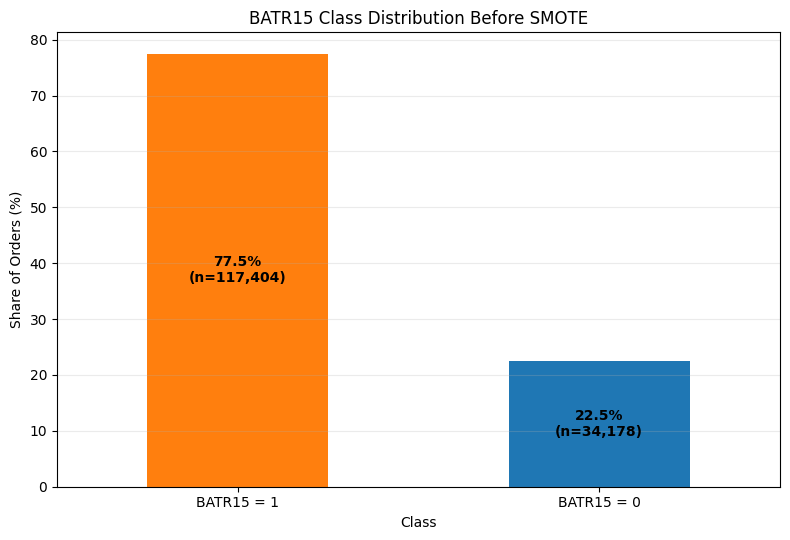

In [4]:
target_counts = model_df["BATR15"].value_counts().sort_index()
target_pct = target_counts / target_counts.sum() * 100

target_table = pd.DataFrame({
    "Orders": target_counts,
    "Share (%)": target_pct
})
display(target_table)

ax = target_pct.loc[[1, 0]].plot(
    kind="bar",
    figsize=(8, 5.5),
    color=["tab:orange", "tab:blue"]
)

for i, status in enumerate([1, 0]):
    ax.text(
        i,
        target_pct.loc[status] / 2,
        f"{target_pct.loc[status]:.1f}%\n(n={target_counts.loc[status]:,})",
        ha="center",
        va="center",
        fontweight="bold"
    )

ax.set_title("BATR15 Class Distribution Before SMOTE")
ax.set_xlabel("Class")
ax.set_ylabel("Share of Orders (%)")
ax.set_xticklabels(["BATR15 = 1", "BATR15 = 0"], rotation=0)
ax.grid(axis="y", alpha=.25)
plt.tight_layout()
plt.show()


,BATR15,month,day,is_weekend,weekday_sin,weekday_cos,batch,order_fare,total_distance,fare_per_km,log_order_fare,log_total_distance
BATR15,1.0000,0.0230,-0.0060,-0.0170,-0.0140,0.0260,0.0180,-0.3110,-0.1000,-0.0000,-0.3160,-0.1090
month,0.0230,1.0000,-0.0300,0.0340,0.0500,-0.0510,0.0830,0.1170,0.0130,-0.0020,0.1230,0.0260
day,-0.0060,-0.0300,1.0000,0.0350,-0.0310,-0.0060,0.0300,0.0430,0.0050,-0.0020,0.0480,0.0060
is_weekend,-0.0170,0.0340,0.0350,1.0000,-0.2680,-0.5200,0.0160,0.0760,0.0110,0.0080,0.0760,0.0110
weekday_sin,-0.0140,0.0500,-0.0310,-0.2680,1.0000,0.0010,0.0040,-0.0170,0.0010,-0.0020,-0.0190,0.0000
weekday_cos,0.0260,-0.0510,-0.0060,-0.5200,0.0010,1.0000,-0.0180,-0.0700,-0.0060,-0.0040,-0.0680,-0.0060
batch,0.0180,0.0830,0.0300,0.0160,0.0040,-0.0180,1.0000,-0.1820,-0.2070,0.0010,-0.1810,-0.1980
order_fare,-0.3110,0.1170,0.0430,0.0760,-0.0170,-0.0700,-0.1820,1.0000,0.7470,-0.0120,0.9600,0.6910
total_distance,-0.1000,0.0130,0.0050,0.0110,0.0010,-0.0060,-0.2070,0.7470,1.0000,-0.0300,0.7380,0.8700
fare_per_km,-0.0000,-0.0020,-0.0020,0.0080,-0.0020,-0.0040,0.0010,-0.0120,-0.0300,1.0000,-0.0150,-0.0910


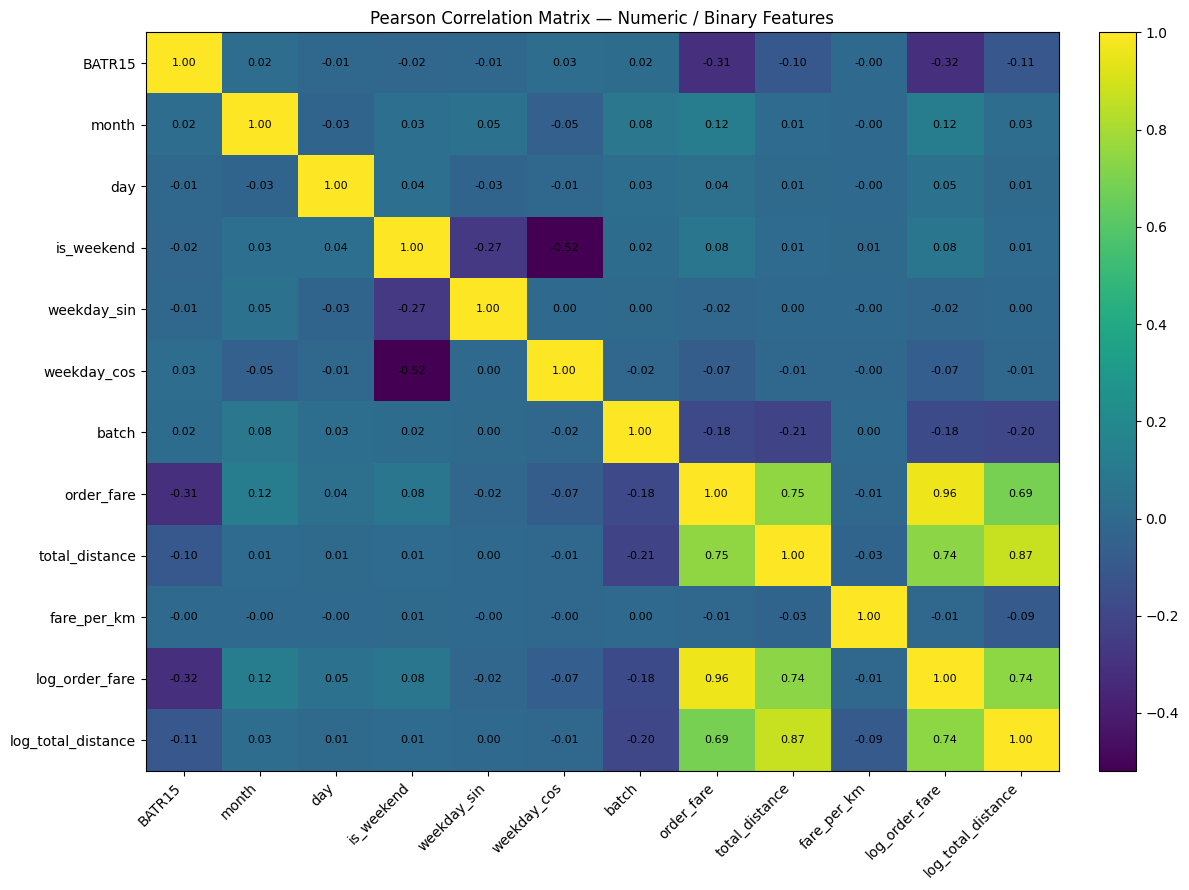

In [5]:
corr_data = pd.DataFrame({
    "BATR15": model_df["BATR15"],
    "month": model_df["month"],
    "day": model_df["day"],
    "is_weekend": model_df["is_weekend"],
    "weekday_sin": model_df["weekday_sin"],
    "weekday_cos": model_df["weekday_cos"],
    "batch": pd.to_numeric(model_df["batch_str"], errors="coerce"),
    "order_fare": model_df["order_fare"],
    "total_distance": model_df["total_distance"],
    "fare_per_km": model_df["fare_per_km"],
    "log_order_fare": model_df["log_order_fare"],
    "log_total_distance": model_df["log_total_distance"]
})

for c in corr_data.columns:
    corr_data[c] = pd.to_numeric(corr_data[c], errors="coerce")
    corr_data[c] = corr_data[c].fillna(corr_data[c].median())

corr = corr_data.corr(method="pearson")

display(corr.round(3))

fig, ax = plt.subplots(figsize=(12, 9))
im = ax.imshow(corr.values, aspect="auto")

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(
            j, i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

ax.set_title("Pearson Correlation Matrix — Numeric / Binary Features")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


In [6]:
for col in [
    "month_name",
    "weekday_name",
    "order_city",
    "district_str",
    "batch_str"
]:
    print("\n" + "="*80)
    print(col)
    print("="*80)

    t = (
        model_df.groupby(col)["BATR15"]
                .agg(Orders="count", BATR15_Rate="mean")
                .reset_index()
    )
    t["BATR15 (%)"] = t["BATR15_Rate"] * 100

    display(
        t.sort_values(
            ["Orders", "BATR15 (%)"],
            ascending=[False, False]
        )
    )



month_name


,month_name,Orders,BATR15_Rate,BATR15 (%)
1,October,60848,0.7786,77.8612
2,September,49565,0.7883,78.8278
0,August,41169,0.7519,75.1925



weekday_name


,weekday_name,Orders,BATR15_Rate,BATR15 (%)
4,Thursday,22914,0.7590,75.8968
0,Friday,22591,0.7572,75.7204
6,Wednesday,21900,0.7672,76.7215
5,Tuesday,21729,0.7796,77.9603
1,Monday,21355,0.7803,78.0286
3,Sunday,20709,0.7982,79.8204
2,Saturday,20384,0.7836,78.3556



order_city


,order_city,Orders,BATR15_Rate,BATR15 (%)
1,K,78888,0.7243,72.4255
2,U,51368,0.7983,79.8337
0,B,21326,0.9031,90.3123



district_str


,district_str,Orders,BATR15_Rate,BATR15 (%)
14,1480,26893,0.7019,70.1856
10,1432,13113,0.8190,81.8958
7,1420,12031,0.8599,85.9945
20,1512,10864,0.6901,69.0077
23,3720,9461,0.9291,92.9077
19,1508,8887,0.8077,80.7697
9,1428,8576,0.7732,77.3204
22,1528,7115,0.6638,66.3809
15,1484,5410,0.6765,67.6525
30,4532,4797,0.8324,83.2395



batch_str


,batch_str,Orders,BATR15_Rate,BATR15 (%)
0,0,133271,0.7717,77.1743
1,1,18311,0.7948,79.4768


In [7]:
X = model_df[feature_cols].copy()
y = model_df["BATR15"].copy()

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

split_table = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Rows": [len(X_train), len(X_val), len(X_test)],
    "BATR15=1 (%)": [
        y_train.mean()*100,
        y_val.mean()*100,
        y_test.mean()*100
    ],
    "BATR15=0 (%)": [
        (1-y_train.mean())*100,
        (1-y_val.mean())*100,
        (1-y_test.mean())*100
    ]
})

display(split_table)


,Split,Rows,BATR15=1 (%),BATR15=0 (%)
0,Train,106107,77.4520,22.5480
1,Validation,22737,77.4552,22.5448
2,Test,22738,77.4518,22.5482


In [8]:
numeric_medians = X_train[numeric_cols].median()

categorical_fill = {}
for col in categorical_cols:
    mode = X_train[col].dropna().mode()
    categorical_fill[col] = mode.iloc[0] if len(mode) else "MISSING"

def fill_features(frame):
    out = frame.copy()

    for col in numeric_cols:
        out[col] = pd.to_numeric(out[col], errors="coerce")
        out[col] = out[col].fillna(numeric_medians[col])

    for col in categorical_cols:
        out[col] = out[col].astype("object")
        out[col] = out[col].where(out[col].notna(), categorical_fill[col])
        out[col] = out[col].astype(str)

    return out

X_train_f = fill_features(X_train)
X_val_f = fill_features(X_val)
X_test_f = fill_features(X_test)




ordinal_encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

ordinal_encoder.fit(X_train_f[categorical_cols])

def to_smote_frame(frame):
    out = pd.DataFrame(index=frame.index)


    for col in numeric_cols:
        out[col] = frame[col].astype(float)

    cat_codes = ordinal_encoder.transform(frame[categorical_cols])

    for j, col in enumerate(categorical_cols):
        out[col] = cat_codes[:, j].astype(int)

    return out

X_train_enc = to_smote_frame(X_train_f)
X_val_enc = to_smote_frame(X_val_f)
X_test_enc = to_smote_frame(X_test_f)

smote_cat_indices = [
    X_train_enc.columns.get_loc(c)
    for c in categorical_cols
]

print("Encoded feature order:")
print(list(X_train_enc.columns))
print("\nCategorical indices used by SMOTENC:")
print(smote_cat_indices)


Encoded feature order:
['month', 'day', 'is_weekend', 'weekday_sin', 'weekday_cos', 'order_fare', 'total_distance', 'fare_per_km', 'log_order_fare', 'log_total_distance', 'month_name', 'weekday_name', 'order_city', 'district_str', 'batch_str', 'city_district']

Categorical indices used by SMOTENC:
[10, 11, 12, 13, 14, 15]


In [9]:
before_smote = y_train.value_counts().sort_index()

smote = SMOTENC(
    categorical_features=smote_cat_indices,
    sampling_strategy="auto",
    random_state=RANDOM_STATE,
    k_neighbors=5
)

X_train_sm, y_train_sm = smote.fit_resample(
    X_train_enc,
    y_train
)


if not isinstance(X_train_sm, pd.DataFrame):
    X_train_sm = pd.DataFrame(
        X_train_sm,
        columns=X_train_enc.columns
    )

after_smote = pd.Series(y_train_sm).value_counts().sort_index()

smote_table = pd.DataFrame({
    "Before SMOTE": before_smote,
    "After SMOTE": after_smote
}).fillna(0).astype(int)

display(smote_table)

print(
    f"Training rows: {len(y_train):,} -> "
    f"{len(y_train_sm):,} after SMOTENC"
)


,Before SMOTE,After SMOTE
BATR15,,
0,23925,82182
1,82182,82182


Training rows: 106,107 -> 164,364 after SMOTENC


In [10]:
postprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(with_mean=False),
            numeric_cols
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            ),
            categorical_cols
        )
    ],
    remainder="drop"
)

X_train_model = postprocessor.fit_transform(X_train_sm)
X_val_model = postprocessor.transform(X_val_enc)
X_test_model = postprocessor.transform(X_test_enc)

print("Train model matrix:", X_train_model.shape)
print("Validation model matrix:", X_val_model.shape)
print("Test model matrix:", X_test_model.shape)


Train model matrix: (164364, 89)
Validation model matrix: (22737, 89)
Test model matrix: (22738, 89)


In [11]:
friendly_feature_names = list(numeric_cols)

ohe = postprocessor.named_transformers_["cat"]

for j, col in enumerate(categorical_cols):
    original_categories = ordinal_encoder.categories_[j]
    encoded_categories = ohe.categories_[j]

    for code in encoded_categories:
        try:
            code_int = int(round(float(code)))
        except Exception:
            code_int = -999

        if 0 <= code_int < len(original_categories):
            label = original_categories[code_int]
        elif code_int == -1:
            label = "UNKNOWN"
        else:
            label = str(code)

        friendly_feature_names.append(f"{col}={label}")

def original_feature_name(transformed_name):
    if transformed_name in numeric_cols:
        return transformed_name

    for col in categorical_cols:
        if transformed_name.startswith(col + "="):
            return col

    return transformed_name

print(f"Transformed features: {len(friendly_feature_names)}")
print(friendly_feature_names[:30])


Transformed features: 89
['month', 'day', 'is_weekend', 'weekday_sin', 'weekday_cos', 'order_fare', 'total_distance', 'fare_per_km', 'log_order_fare', 'log_total_distance', 'month_name=August', 'month_name=October', 'month_name=September', 'weekday_name=Friday', 'weekday_name=Monday', 'weekday_name=Saturday', 'weekday_name=Sunday', 'weekday_name=Thursday', 'weekday_name=Tuesday', 'weekday_name=Wednesday', 'order_city=B', 'order_city=K', 'order_city=U', 'district_str=1392', 'district_str=1396', 'district_str=1400', 'district_str=1404', 'district_str=1408', 'district_str=1412', 'district_str=1416']


In [12]:
mi_X = X_train_enc.copy()

discrete_mask = np.array([
    c in categorical_cols or c == "is_weekend"
    for c in mi_X.columns
])

mi = mutual_info_classif(
    mi_X,
    y_train,
    discrete_features=discrete_mask,
    random_state=RANDOM_STATE
)

mi_table = pd.DataFrame({
    "Feature": mi_X.columns,
    "Mutual Information": mi
}).sort_values("Mutual Information", ascending=False)

display(mi_table)


,Feature,Mutual Information
8,log_order_fare,0.0577
5,order_fare,0.0573
7,fare_per_km,0.0268
13,district_str,0.0193
15,city_district,0.0193
6,total_distance,0.0122
12,order_city,0.0119
9,log_total_distance,0.0115
4,weekday_cos,0.0057
0,month,0.0051


In [13]:
models = {
    "CatBoost": CatBoostClassifier(
        iterations=180,
        depth=6,
        learning_rate=0.06,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=RANDOM_STATE,
        verbose=False,
        thread_count=-1
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=250,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        subsample=0.90,
        colsample_bytree=0.90,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=6,
        min_child_weight=2,
        subsample=0.90,
        colsample_bytree=0.90,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_model, y_train_sm)

print("All three models trained.")


Training CatBoost...
Training LightGBM...
Training XGBoost...
All three models trained.


In [14]:
def metrics_for_late(y_true, prob_success, late_threshold=0.50):
    prob_success = np.asarray(prob_success)
    prob_late = 1 - prob_success

    pred_batr15 = np.where(
        prob_late >= late_threshold,
        0,
        1
    )

    y_true_arr = np.asarray(y_true)
    y_late = 1 - y_true_arr
    pred_late = 1 - pred_batr15

    return {
        "Accuracy": accuracy_score(y_true_arr, pred_batr15),
        "Balanced Accuracy": balanced_accuracy_score(y_true_arr, pred_batr15),
        "Late Precision": precision_score(y_late, pred_late, zero_division=0),
        "Late Recall": recall_score(y_late, pred_late, zero_division=0),
        "Late F1": f1_score(y_late, pred_late, zero_division=0),
        "ROC-AUC (Late)": roc_auc_score(y_late, prob_late),
        "PR-AUC (Late)": average_precision_score(y_late, prob_late)
    }

val_prob_success = {
    name: model.predict_proba(X_val_model)[:, 1]
    for name, model in models.items()
}

validation_rows = []

for name, prob in val_prob_success.items():
    row = metrics_for_late(y_val, prob, late_threshold=0.50)
    row["Model"] = name
    validation_rows.append(row)

validation_results = pd.DataFrame(validation_rows)[
    [
        "Model",
        "Accuracy",
        "Balanced Accuracy",
        "Late Precision",
        "Late Recall",
        "Late F1",
        "ROC-AUC (Late)",
        "PR-AUC (Late)"
    ]
].sort_values("PR-AUC (Late)", ascending=False)

display(validation_results)


,Model,Accuracy,Balanced Accuracy,Late Precision,Late Recall,Late F1,ROC-AUC (Late),PR-AUC (Late)
1,LightGBM,0.8528,0.7444,0.7325,0.5470,0.6263,0.8604,0.6748
2,XGBoost,0.8503,0.7414,0.7241,0.5431,0.6207,0.8561,0.6668
0,CatBoost,0.8487,0.7372,0.7227,0.5339,0.6142,0.8532,0.6599


In [15]:
model_order = ["CatBoost", "LightGBM", "XGBoost"]
y_val_late = 1 - y_val.to_numpy()

weight_rows = []

grid = np.arange(0, 1.0001, 0.05)

for w_cat in grid:
    for w_lgb in grid:
        w_xgb = 1.0 - w_cat - w_lgb

        if w_xgb < -1e-9:
            continue

        w_xgb = max(0.0, w_xgb)


        if min(w_cat, w_lgb, w_xgb) < 0.05 - 1e-9:
            continue

        ensemble_success = (
            w_cat * val_prob_success["CatBoost"]
            + w_lgb * val_prob_success["LightGBM"]
            + w_xgb * val_prob_success["XGBoost"]
        )

        ensemble_late = 1 - ensemble_success

        weight_rows.append({
            "CatBoost weight": w_cat,
            "LightGBM weight": w_lgb,
            "XGBoost weight": w_xgb,
            "Validation PR-AUC (Late)": average_precision_score(
                y_val_late,
                ensemble_late
            ),
            "Validation ROC-AUC (Late)": roc_auc_score(
                y_val_late,
                ensemble_late
            )
        })

weight_search = pd.DataFrame(weight_rows).sort_values(
    ["Validation PR-AUC (Late)", "Validation ROC-AUC (Late)"],
    ascending=False
)

best_weight_row = weight_search.iloc[0]

ensemble_weights = {
    "CatBoost": float(best_weight_row["CatBoost weight"]),
    "LightGBM": float(best_weight_row["LightGBM weight"]),
    "XGBoost": float(best_weight_row["XGBoost weight"])
}

display(weight_search.head(15))

print("Selected soft-voting weights:")
for name in model_order:
    print(f"  {name}: {ensemble_weights[name]:.2f}")
print(f"  Sum: {sum(ensemble_weights.values()):.2f}")


,CatBoost weight,LightGBM weight,XGBoost weight,Validation PR-AUC (Late),Validation ROC-AUC (Late)
17,0.0500,0.9000,0.0500,0.6746,0.8602
34,0.1000,0.8500,0.0500,0.6744,0.8601
16,0.0500,0.8500,0.1000,0.6744,0.8601
33,0.1000,0.8000,0.1000,0.6743,0.8600
15,0.0500,0.8000,0.1500,0.6742,0.8600
50,0.1500,0.8000,0.0500,0.6742,0.8599
14,0.0500,0.7500,0.2000,0.6741,0.8599
32,0.1000,0.7500,0.1500,0.6741,0.8598
49,0.1500,0.7500,0.1000,0.6739,0.8598
13,0.0500,0.7000,0.2500,0.6738,0.8597


Selected soft-voting weights:
  CatBoost: 0.05
  LightGBM: 0.90
  XGBoost: 0.05
  Sum: 1.00


In [77]:
ensemble_weights = {
    "CatBoost": 0.15,
    "LightGBM": 0.50,
    "XGBoost": 0.35
}


In [78]:
def weighted_success_probability(prob_dict, weights):
    result = np.zeros_like(
        next(iter(prob_dict.values())),
        dtype=float
    )

    for name, weight in weights.items():
        result += weight * np.asarray(prob_dict[name])

    return result

val_ensemble_prob_success = weighted_success_probability(
    val_prob_success,
    ensemble_weights
)

ensemble_default_metrics = metrics_for_late(
    y_val,
    val_ensemble_prob_success,
    late_threshold=0.50
)

display(
    pd.DataFrame(
        [ensemble_default_metrics],
        index=["Weighted Soft-Voting Ensemble"]
    )
)


,Accuracy,Balanced Accuracy,Late Precision,Late Recall,Late F1,ROC-AUC (Late),PR-AUC (Late)
Weighted Soft-Voting Ensemble,0.8513,0.7423,0.7279,0.5437,0.6224,0.8589,0.6725


In [70]:
val_ensemble_prob_late = 1 - val_ensemble_prob_success

threshold_grid = np.arange(0.10, 0.91, 0.01)
threshold_rows = []

for threshold in threshold_grid:
    pred_late = (val_ensemble_prob_late >= threshold).astype(int)

    threshold_rows.append({
        "Late Risk Threshold": threshold,
        "Late Precision": precision_score(
            y_val_late, pred_late, zero_division=0
        ),
        "Late Recall": recall_score(
            y_val_late, pred_late, zero_division=0
        ),
        "Late F1": f1_score(
            y_val_late, pred_late, zero_division=0
        )
    })

threshold_table = pd.DataFrame(threshold_rows)
best_threshold_row = threshold_table.loc[
    threshold_table["Late F1"].idxmax()
]
best_late_threshold = float(
    best_threshold_row["Late Risk Threshold"]
)

display(
    threshold_table.sort_values(
        "Late F1",
        ascending=False
    ).head(15)
)

print(f"Selected ensemble late-risk threshold: {best_late_threshold:.2f}")


,Late Risk Threshold,Late Precision,Late Recall,Late F1
24,0.3400,0.6252,0.6812,0.6520
25,0.3500,0.6337,0.6703,0.6515
26,0.3600,0.6427,0.6594,0.6509
23,0.3300,0.6140,0.6896,0.6496
29,0.3900,0.6660,0.6321,0.6486
27,0.3700,0.6485,0.6475,0.6480
28,0.3800,0.6564,0.6391,0.6476
30,0.4000,0.6725,0.6217,0.6461
22,0.3200,0.6021,0.6964,0.6459
21,0.3100,0.5918,0.7097,0.6454


Selected ensemble late-risk threshold: 0.34


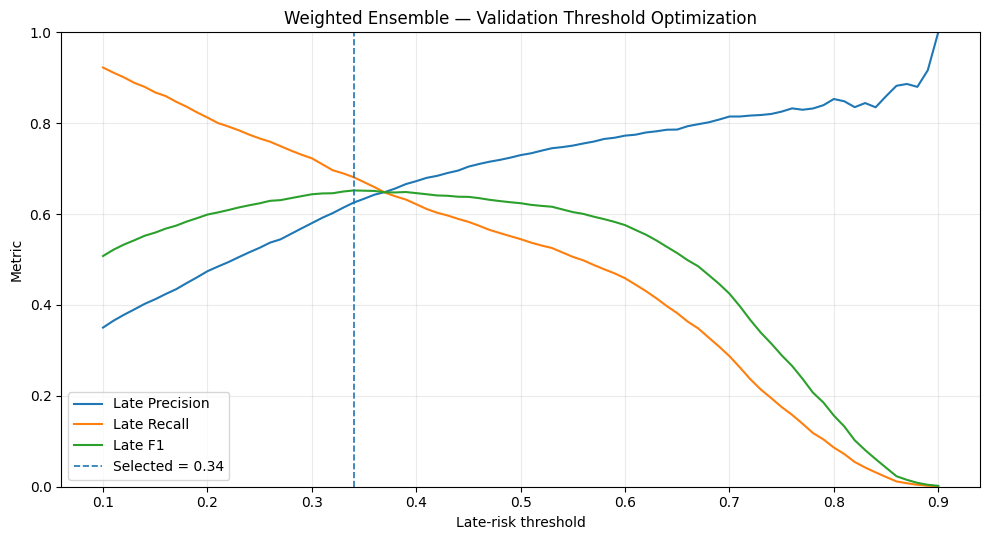

In [71]:
fig, ax = plt.subplots(figsize=(10, 5.5))

ax.plot(
    threshold_table["Late Risk Threshold"],
    threshold_table["Late Precision"],
    label="Late Precision"
)
ax.plot(
    threshold_table["Late Risk Threshold"],
    threshold_table["Late Recall"],
    label="Late Recall"
)
ax.plot(
    threshold_table["Late Risk Threshold"],
    threshold_table["Late F1"],
    label="Late F1"
)

ax.axvline(
    best_late_threshold,
    linestyle="--",
    linewidth=1.2,
    label=f"Selected = {best_late_threshold:.2f}"
)

ax.set_title("Weighted Ensemble — Validation Threshold Optimization")
ax.set_xlabel("Late-risk threshold")
ax.set_ylabel("Metric")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(alpha=.25)

plt.tight_layout()
plt.show()


,Accuracy,Balanced Accuracy,Late Precision,Late Recall,Late F1,ROC-AUC (Late),PR-AUC (Late)
Weighted Soft-Voting Ensemble,0.8324,0.7787,0.6163,0.6807,0.6469,0.8571,0.6690


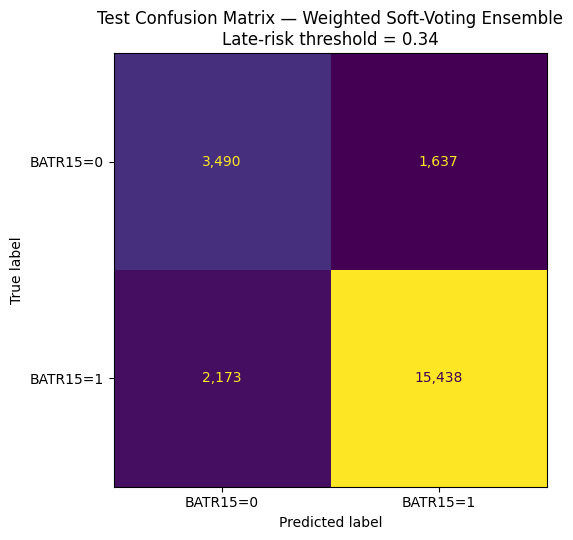

In [72]:
test_prob_success = {
    name: model.predict_proba(X_test_model)[:, 1]
    for name, model in models.items()
}

test_ensemble_prob_success = weighted_success_probability(
    test_prob_success,
    ensemble_weights
)

test_ensemble_prob_late = 1 - test_ensemble_prob_success

test_metrics = metrics_for_late(
    y_test,
    test_ensemble_prob_success,
    late_threshold=best_late_threshold
)

test_results = pd.DataFrame(
    [test_metrics],
    index=["Weighted Soft-Voting Ensemble"]
)

display(test_results)

test_pred = np.where(
    test_ensemble_prob_late >= best_late_threshold,
    0,
    1
)

cm = confusion_matrix(
    y_test,
    test_pred,
    labels=[0, 1]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["BATR15=0", "BATR15=1"]
)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
disp.plot(ax=ax, values_format=",", colorbar=False)
ax.set_title(
    "Test Confusion Matrix — Weighted Soft-Voting Ensemble\n"
    f"Late-risk threshold = {best_late_threshold:.2f}"
)
plt.tight_layout()
plt.show()


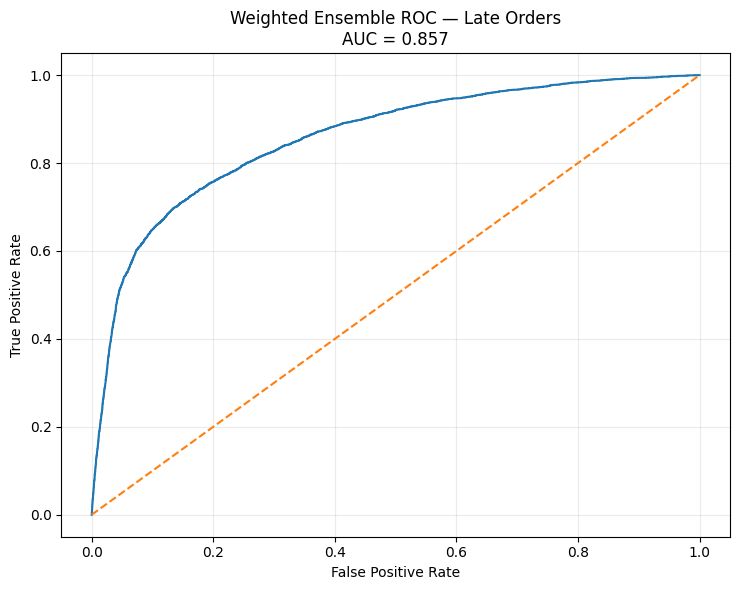

In [73]:
y_test_late = 1 - y_test.to_numpy()

fpr, tpr, _ = roc_curve(
    y_test_late,
    test_ensemble_prob_late
)

fig, ax = plt.subplots(figsize=(7.5, 6))
ax.plot(fpr, tpr)
ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_title(
    "Weighted Ensemble ROC — Late Orders\n"
    f"AUC = {test_metrics['ROC-AUC (Late)']:.3f}"
)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.grid(alpha=.25)
plt.tight_layout()
plt.show()


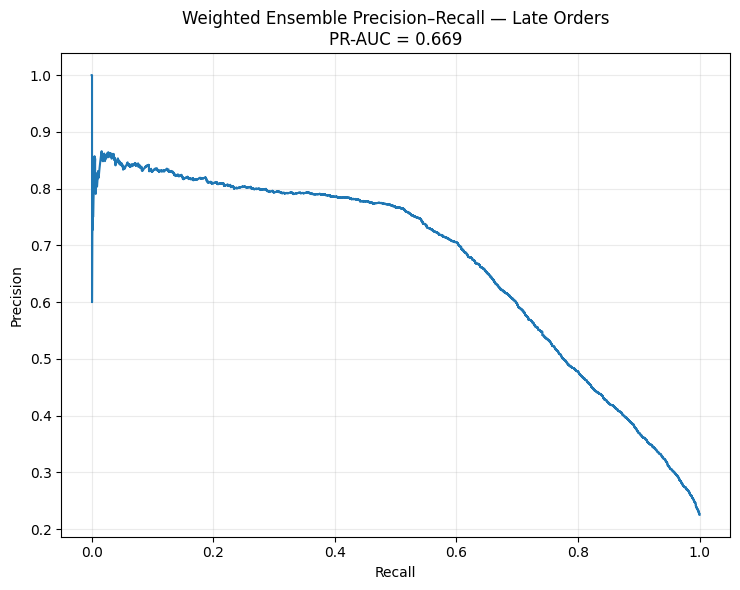

In [74]:
precision, recall, _ = precision_recall_curve(
    y_test_late,
    test_ensemble_prob_late
)

fig, ax = plt.subplots(figsize=(7.5, 6))
ax.plot(recall, precision)
ax.set_title(
    "Weighted Ensemble Precision–Recall — Late Orders\n"
    f"PR-AUC = {test_metrics['PR-AUC (Late)']:.3f}"
)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.grid(alpha=.25)
plt.tight_layout()
plt.show()


In [75]:
test_comparison_rows = []

for name, prob in test_prob_success.items():
    row = metrics_for_late(
        y_test,
        prob,
        late_threshold=best_late_threshold
    )
    row["Model"] = name
    test_comparison_rows.append(row)

ensemble_row = metrics_for_late(
    y_test,
    test_ensemble_prob_success,
    late_threshold=best_late_threshold
)
ensemble_row["Model"] = "Weighted Soft-Voting Ensemble"
test_comparison_rows.append(ensemble_row)

test_comparison = pd.DataFrame(test_comparison_rows)[
    [
        "Model",
        "Accuracy",
        "Balanced Accuracy",
        "Late Precision",
        "Late Recall",
        "Late F1",
        "ROC-AUC (Late)",
        "PR-AUC (Late)"
    ]
].sort_values("PR-AUC (Late)", ascending=False)

display(test_comparison)


,Model,Accuracy,Balanced Accuracy,Late Precision,Late Recall,Late F1,ROC-AUC (Late),PR-AUC (Late)
1,LightGBM,0.8361,0.7801,0.6261,0.6782,0.6511,0.8582,0.6704
3,Weighted Soft-Voting Ensemble,0.8324,0.7787,0.6163,0.6807,0.6469,0.8571,0.6690
2,XGBoost,0.8272,0.7781,0.6023,0.6887,0.6426,0.8542,0.6636
0,CatBoost,0.8220,0.7740,0.5905,0.6868,0.6350,0.8512,0.6579


,Original Feature,Ensemble weighted importance
0,weekday_name,0.1222
1,city_district,0.1060
2,district_str,0.1059
3,order_fare,0.0946
4,month,0.0904
5,fare_per_km,0.0792
6,weekday_cos,0.0694
7,weekday_sin,0.0638
8,is_weekend,0.0632
9,month_name,0.0569


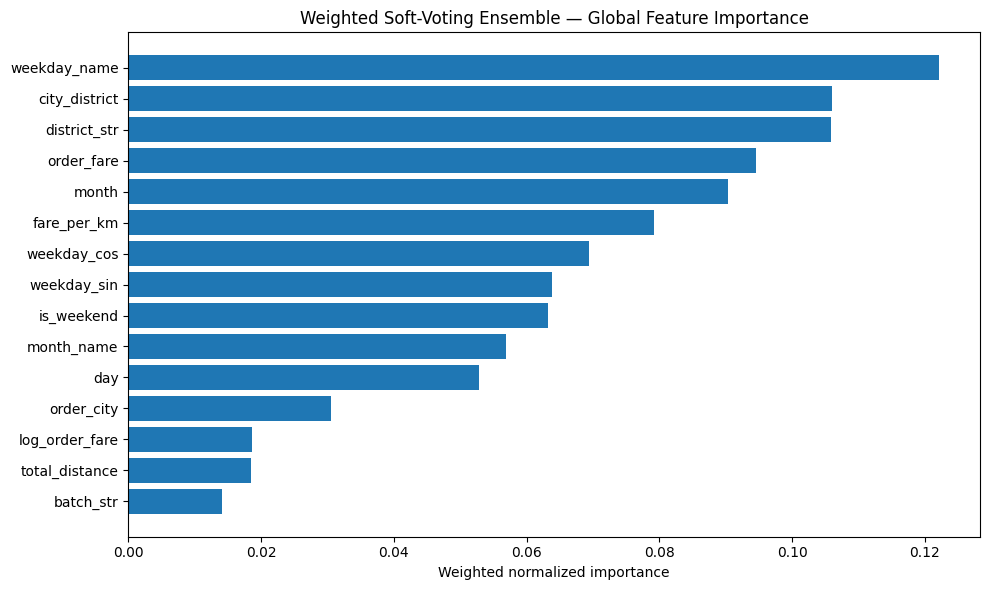

In [76]:
importance_by_model = {}

for name, model in models.items():
    raw = np.asarray(model.feature_importances_, dtype=float)

    if raw.sum() > 0:
        normalized = raw / raw.sum()
    else:
        normalized = raw

    importance_by_model[name] = normalized

importance_detail = pd.DataFrame({
    "Transformed Feature": friendly_feature_names
})

for name in model_order:
    importance_detail[f"{name} normalized importance"] = (
        importance_by_model[name]
    )

importance_detail["Ensemble weighted importance"] = 0.0

for name in model_order:
    importance_detail["Ensemble weighted importance"] += (
        ensemble_weights[name]
        * importance_detail[f"{name} normalized importance"]
    )

importance_detail["Original Feature"] = importance_detail[
    "Transformed Feature"
].apply(original_feature_name)

ensemble_importance = (
    importance_detail
    .groupby("Original Feature")["Ensemble weighted importance"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

display(ensemble_importance)

fig, ax = plt.subplots(figsize=(10, 6))
top_imp = ensemble_importance.head(15).sort_values(
    "Ensemble weighted importance",
    ascending=True
)

ax.barh(
    top_imp["Original Feature"],
    top_imp["Ensemble weighted importance"]
)
ax.set_title("Weighted Soft-Voting Ensemble — Global Feature Importance")
ax.set_xlabel("Weighted normalized importance")
plt.tight_layout()
plt.show()


,Original Feature,Mean |SHAP|
0,month,1.5900
1,weekday_name,1.1156
2,weekday_cos,1.0871
3,order_fare,0.8861
4,fare_per_km,0.7646
5,weekday_sin,0.7178
6,month_name,0.6890
7,district_str,0.3852
8,city_district,0.3262
9,is_weekend,0.1911


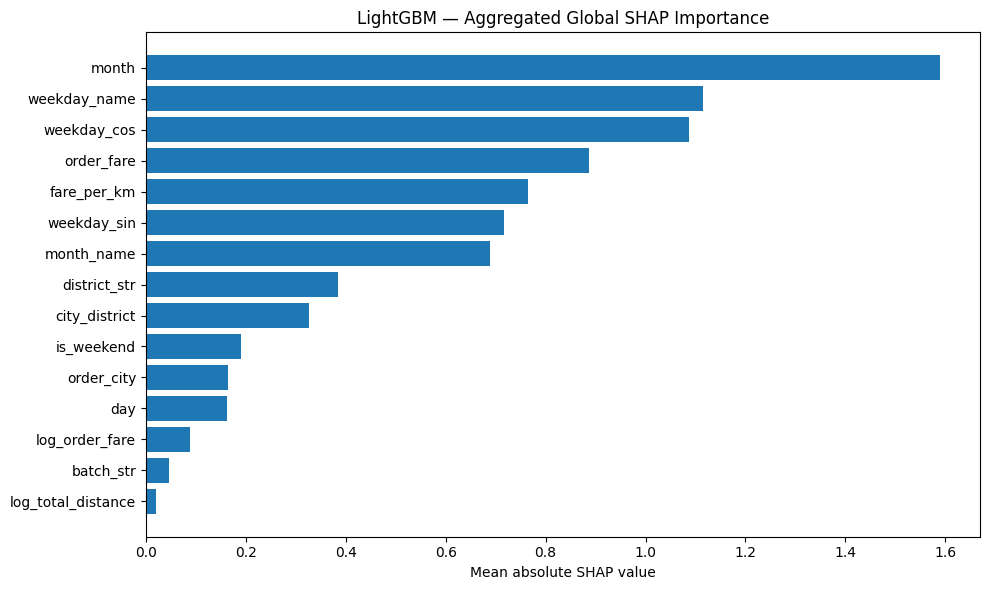

In [24]:
lgbm_model = models["LightGBM"]


shap_n = min(500, X_test_model.shape[0])

shap_idx = np.random.RandomState(RANDOM_STATE).choice(
    X_test_model.shape[0],
    size=shap_n,
    replace=False
)

X_shap = X_test_model[shap_idx]


if hasattr(X_shap, "toarray"):
    X_shap_dense = X_shap.toarray()
else:
    X_shap_dense = np.asarray(X_shap)

explainer = shap.TreeExplainer(lgbm_model)
shap_values_raw = explainer.shap_values(X_shap_dense)

if isinstance(shap_values_raw, list):
    shap_values = (
        shap_values_raw[1]
        if len(shap_values_raw) == 2
        else shap_values_raw[0]
    )
else:
    shap_values = np.asarray(shap_values_raw)

if shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]

mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_detail = pd.DataFrame({
    "Transformed Feature": friendly_feature_names,
    "Mean |SHAP|": mean_abs_shap
})

shap_detail["Original Feature"] = shap_detail[
    "Transformed Feature"
].apply(original_feature_name)

shap_agg = (
    shap_detail.groupby("Original Feature")["Mean |SHAP|"]
               .sum()
               .sort_values(ascending=False)
               .reset_index()
)

display(shap_agg)

fig, ax = plt.subplots(figsize=(10, 6))
top_shap = shap_agg.head(15).sort_values(
    "Mean |SHAP|",
    ascending=True
)

ax.barh(
    top_shap["Original Feature"],
    top_shap["Mean |SHAP|"]
)
ax.set_title("LightGBM — Aggregated Global SHAP Importance")
ax.set_xlabel("Mean absolute SHAP value")
plt.tight_layout()
plt.show()


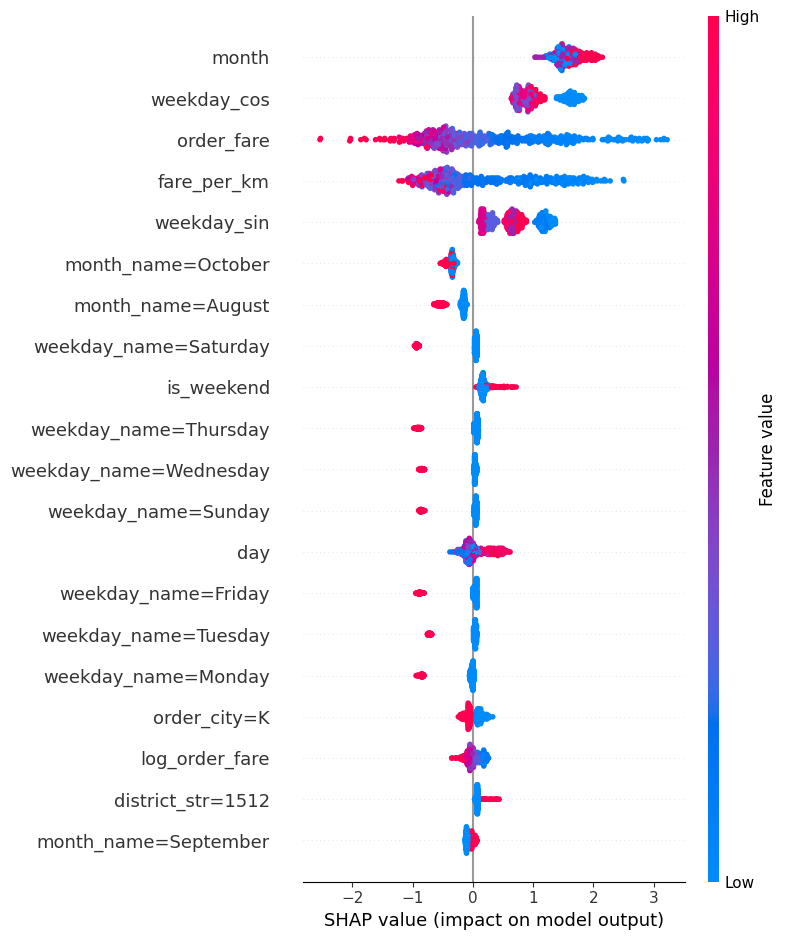

In [25]:
shap.summary_plot(
    shap_values,
    X_shap_dense,
    feature_names=friendly_feature_names,
    max_display=20,
    show=True
)


In [26]:
def make_feature_row(
    created_date,
    order_city,
    district,
    batch,
    order_fare,
    total_distance
):
    created_date = pd.to_datetime(created_date)

    month = created_date.month
    month_name = created_date.month_name()
    day = created_date.day
    weekday_num = created_date.dayofweek
    weekday_name = created_date.day_name()

    is_weekend = int(weekday_name == "Friday")

    weekday_sin = np.sin(2 * np.pi * weekday_num / 7)
    weekday_cos = np.cos(2 * np.pi * weekday_num / 7)

    district_str = str(int(district))
    batch_str = str(int(batch))
    city_district = f"{order_city}_{district_str}"

    distance_km = total_distance / 1000.0

    fare_per_km = (
        order_fare / distance_km
        if distance_km > 0
        else np.nan
    )

    log_order_fare = np.log1p(max(order_fare, 0))
    log_total_distance = np.log1p(max(total_distance, 0))

    row = pd.DataFrame([{
        "month_name": month_name,
        "weekday_name": weekday_name,
        "order_city": str(order_city),
        "district_str": district_str,
        "batch_str": batch_str,
        "city_district": city_district,
        "month": month,
        "day": day,
        "is_weekend": is_weekend,
        "weekday_sin": weekday_sin,
        "weekday_cos": weekday_cos,
        "order_fare": order_fare,
        "total_distance": total_distance,
        "fare_per_km": fare_per_km,
        "log_order_fare": log_order_fare,
        "log_total_distance": log_total_distance
    }])

    return row[feature_cols]


def transform_new_orders(feature_frame):
    filled = fill_features(feature_frame)
    encoded = to_smote_frame(filled)
    return postprocessor.transform(encoded)


def predict_new_order(
    created_date,
    order_city,
    district,
    batch,
    order_fare,
    total_distance
):
    row = make_feature_row(
        created_date=created_date,
        order_city=order_city,
        district=district,
        batch=batch,
        order_fare=order_fare,
        total_distance=total_distance
    )

    X_new = transform_new_orders(row)

    component_probs = {
        name: float(model.predict_proba(X_new)[0, 1])
        for name, model in models.items()
    }

    ensemble_prob_success = sum(
        ensemble_weights[name] * component_probs[name]
        for name in model_order
    )

    late_risk = 1 - ensemble_prob_success

    predicted_batr15 = (
        0 if late_risk >= best_late_threshold else 1
    )

    return pd.DataFrame([{
        "CatBoost P(BATR15=1)": component_probs["CatBoost"],
        "LightGBM P(BATR15=1)": component_probs["LightGBM"],
        "XGBoost P(BATR15=1)": component_probs["XGBoost"],
        "Ensemble P(BATR15=1)": ensemble_prob_success,
        "Ensemble Late Risk P(BATR15=0)": late_risk,
        "Late-risk threshold": best_late_threshold,
        "Predicted BATR15": predicted_batr15
    }])



predict_new_order(
    created_date="2025-10-15",
    order_city="K",
    district=1480,
    batch=0,
    order_fare=1_100_000,
    total_distance=3500
)


,CatBoost P(BATR15=1),LightGBM P(BATR15=1),XGBoost P(BATR15=1),Ensemble P(BATR15=1),Ensemble Late Risk P(BATR15=0),Late-risk threshold,Predicted BATR15
0,0.7005,0.7698,0.7342,0.7646,0.2354,0.3500,1


In [27]:
print("FINAL ARCHITECTURE")
print("="*75)
print("Weighted Soft-Voting Ensemble")
print()

print("LEARNED WEIGHTS")
for name in model_order:
    print(f"{name}: {ensemble_weights[name]:.2f}")
print()

print(f"Final late-risk threshold: {best_late_threshold:.2f}")
print()

print("FINAL TEST PERFORMANCE")
display(test_results)

print("TOP 10 ENSEMBLE-WEIGHTED FEATURES")
display(ensemble_importance.head(10))

print("TOP 10 LIGHTGBM SHAP FEATURES")
display(shap_agg.head(10))


FINAL ARCHITECTURE
Weighted Soft-Voting Ensemble

LEARNED WEIGHTS
CatBoost: 0.05
LightGBM: 0.90
XGBoost: 0.05

Final late-risk threshold: 0.35

FINAL TEST PERFORMANCE


,Accuracy,Balanced Accuracy,Late Precision,Late Recall,Late F1,ROC-AUC (Late),PR-AUC (Late)
Weighted Soft-Voting Ensemble,0.8376,0.7779,0.6323,0.6690,0.6501,0.8580,0.6702


TOP 10 ENSEMBLE-WEIGHTED FEATURES


,Original Feature,Ensemble weighted importance
0,order_fare,0.1291
1,fare_per_km,0.1085
2,city_district,0.1048
3,weekday_name,0.1040
4,district_str,0.1022
5,month,0.0859
6,day,0.0778
7,month_name,0.0504
8,weekday_cos,0.0493
9,weekday_sin,0.0460


TOP 10 LIGHTGBM SHAP FEATURES


,Original Feature,Mean |SHAP|
0,month,1.5900
1,weekday_name,1.1156
2,weekday_cos,1.0871
3,order_fare,0.8861
4,fare_per_km,0.7646
5,weekday_sin,0.7178
6,month_name,0.6890
7,district_str,0.3852
8,city_district,0.3262
9,is_weekend,0.1911
